<div style="border: 5px solid black; border-radius: 8px; padding: 20px;">

### **Course:** DSC630 — Predictive Analytics
### **Name:** Tim Hollis
### **Assignment:** Milestone 3 Visualizations
### **Date:** 04/22/2026

</div>

In [6]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Visualization settings
sns.set_theme(style='whitegrid')
PALETTE = ['#4169E1', '#4B0082', '#228B22', '#8B0000', '#FF8C00']
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

# load dataset
df = pd.read_csv('fake_job_postings.csv').copy()

# Preview data
print(f'✅ Dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns')
print(f'🔍 Columns: {df.columns.tolist()}')
print(f'\n📊 Class distribution:')
print(df['fraudulent'].value_counts())
print(f'\n🕳️ Missing values:')
print(df.isnull().sum())

✅ Dataset loaded: 17,880 rows, 18 columns
🔍 Columns: ['job_id', 'title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent']

📊 Class distribution:
fraudulent
0    17014
1      866
Name: count, dtype: int64

🕳️ Missing values:
job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64


## **Milestone 3 Visualizations**

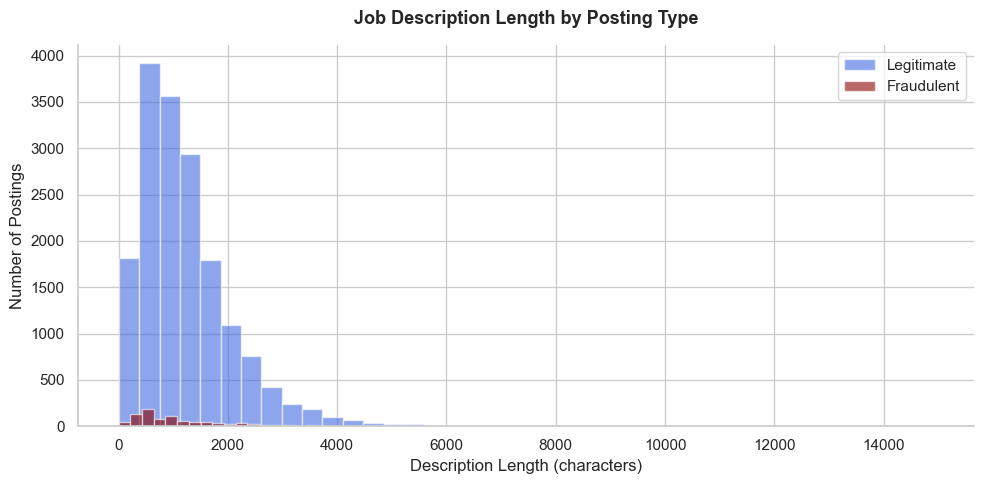


Analysis — Graph 1:
Legitimate postings show a mean description length of 1221 characters compared to 1155 characters for fraudulent postings.
This difference suggests that fraudulent postings tend to use shorter, less detailed descriptions — consistent with the hypothesis that
bad actors invest less effort in crafting realistic job listings. Description length will be engineered as a numeric feature in Milestone 4.



In [7]:
# Graph 1: Description length by fraud status
df['desc_length'] = df['description'].fillna('').apply(len)

fig, ax = plt.subplots()
for label, color, name in zip([0, 1], [PALETTE[0], PALETTE[3]],
                              ['Legitimate', 'Fraudulent']):
    subset = df[df['fraudulent'] == label]['desc_length']
    ax.hist(
        subset,
        bins=40,
        alpha=0.6,
        color=color,
        label=name,
        edgecolor='white')

ax.set_title('Job Description Length by Posting Type',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Description Length (characters)')
ax.set_ylabel('Number of Postings')
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig('graph1_desc_length.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"""
Analysis — Graph 1:
Legitimate postings show a mean description length of {df[df['fraudulent']==0]['desc_length'].mean():.0f} characters compared to {df[df['fraudulent']==1]['desc_length'].mean():.0f} characters for fraudulent postings.
This difference suggests that fraudulent postings tend to use shorter, less detailed descriptions — consistent with the hypothesis that
bad actors invest less effort in crafting realistic job listings. Description length will be engineered as a numeric feature in Milestone 4.
""")

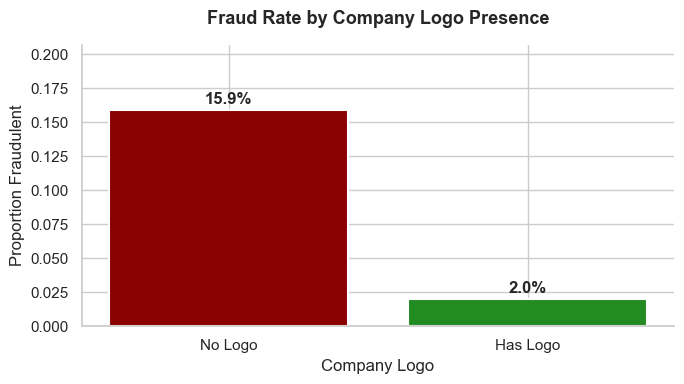


Analysis — Graph 2:
Postings without a company logo show a fraud rate of 15.9% compared to
just 2.0% for postings that include one — nearly an eight-fold difference.
This is one of the strongest single-feature fraud signals identified in the
dataset. The absence of a company logo is a completely observed boolean
feature with no missing values, making it an ideal candidate for inclusion
in both the logistic regression baseline and the Random Forest model.



In [8]:
# Graph 2: Fraud rate by company logo
logo_fraud = df.groupby('has_company_logo')['fraudulent'].mean()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(['No Logo', 'Has Logo'], logo_fraud.values,
              color=[PALETTE[3], PALETTE[2]], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, logo_fraud.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
            f'{val:.1%}', ha='center', va='bottom',
            fontsize=12, fontweight='bold')
ax.set_title('Fraud Rate by Company Logo Presence',
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Proportion Fraudulent')
ax.set_xlabel('Company Logo')
ax.set_ylim(0, logo_fraud.max() * 1.3)
sns.despine()
plt.tight_layout()
plt.savefig('graph2_logo.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
Analysis — Graph 2:
Postings without a company logo show a fraud rate of 15.9% compared to
just 2.0% for postings that include one — nearly an eight-fold difference.
This is one of the strongest single-feature fraud signals identified in the
dataset. The absence of a company logo is a completely observed boolean
feature with no missing values, making it an ideal candidate for inclusion
in both the logistic regression baseline and the Random Forest model.
""")

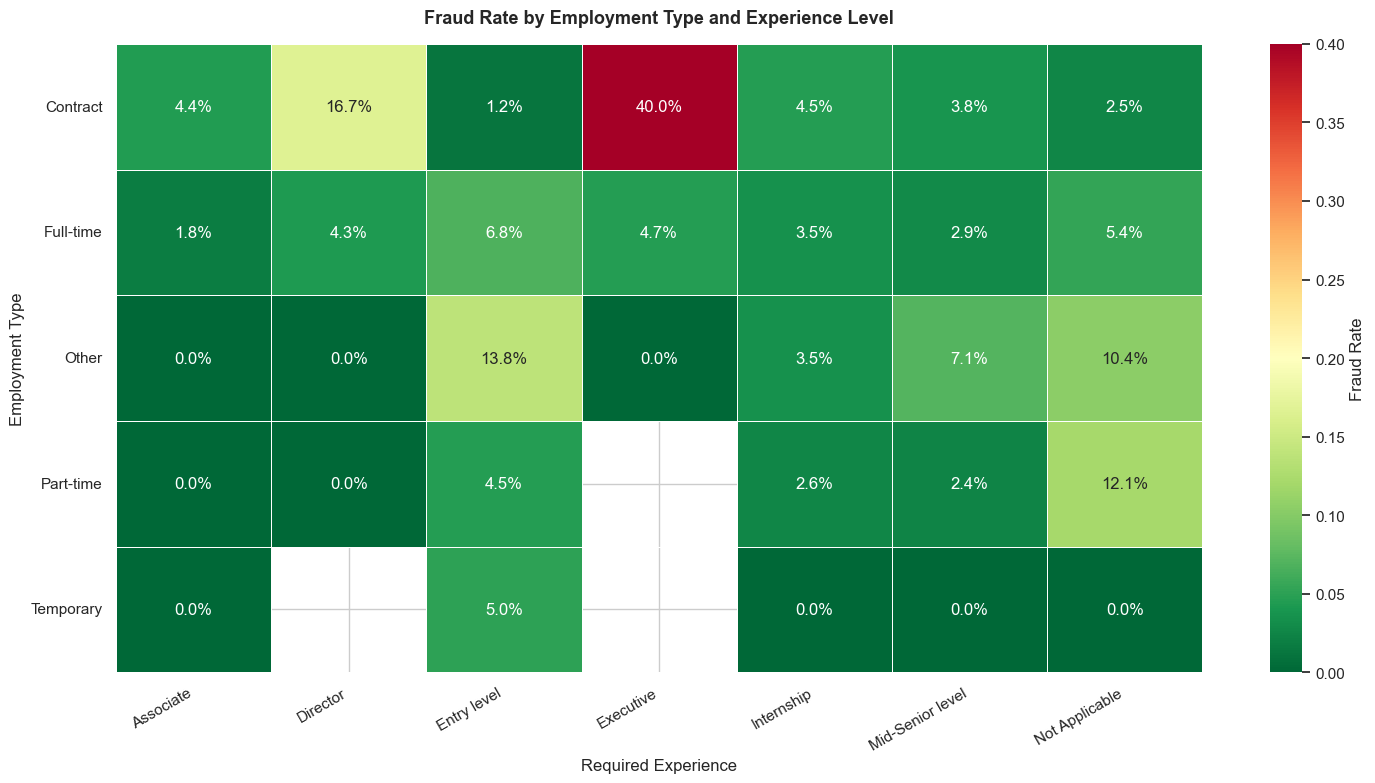


Analysis — Graph 3:
The heatmap reveals striking interaction effects between employment type and
experience level that neither variable captures alone. The most alarming cell
is Contract/Executive at 40.0% — meaning 4 in 10 contract postings targeting
executive-level candidates are fraudulent, nearly eight times the overall
dataset rate of 4.8%. Director-level contract postings also show an elevated
rate of 16.7%. This pattern suggests fraudulent actors specifically target
high-prestige contract roles, likely because the promise of a lucrative
executive opportunity makes victims less skeptical.

On the other end of the spectrum, temporary postings show 0.0% fraud across
nearly all experience levels, and part-time associate and director roles
similarly show no detected fraud. The concentration of fraud in specific
cells rather than being evenly distributed across the matrix confirms that
the interaction between employment type and experience level carries
meaningful predictive signal b

In [9]:
# Graph 3: Heatmap — fraud rate by employment type and required experience
pivot = df.groupby(['employment_type', 'required_experience'])[
    'fraudulent'].mean().unstack()

fig, ax = plt.subplots(figsize=(15, 8))
sns.heatmap(pivot, annot=True, fmt='.1%', cmap='RdYlGn_r',
            linewidths=0.5, linecolor='white',
            ax=ax, cbar_kws={'label': 'Fraud Rate'})

ax.set_title('Fraud Rate by Employment Type and Experience Level',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Required Experience')
ax.set_ylabel('Employment Type')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('graph3_fraud_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
Analysis — Graph 3:
The heatmap reveals striking interaction effects between employment type and
experience level that neither variable captures alone. The most alarming cell
is Contract/Executive at 40.0% — meaning 4 in 10 contract postings targeting
executive-level candidates are fraudulent, nearly eight times the overall
dataset rate of 4.8%. Director-level contract postings also show an elevated
rate of 16.7%. This pattern suggests fraudulent actors specifically target
high-prestige contract roles, likely because the promise of a lucrative
executive opportunity makes victims less skeptical.

On the other end of the spectrum, temporary postings show 0.0% fraud across
nearly all experience levels, and part-time associate and director roles
similarly show no detected fraud. The concentration of fraud in specific
cells rather than being evenly distributed across the matrix confirms that
the interaction between employment type and experience level carries
meaningful predictive signal beyond either feature individually. Both
variables will be retained and their interaction will be considered during
feature engineering in Milestone 4.
""")

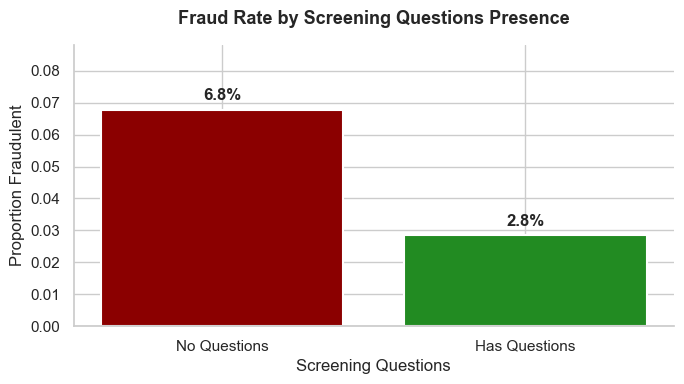


Analysis — Graph 4:
Postings without screening questions show a fraud rate of 6.8% compared
to 2.8% for postings that include them — more than double the rate.
Screening questions require effort to create and suggest a legitimate
hiring process, so their absence may signal a posting designed to collect
personal information rather than evaluate candidates. Like the company logo
feature, has_questions is fully observed with no missing values and will
be included as a binary feature in both models.



In [10]:
# Graph 4: Fraud rate by screening questions
q_fraud = df.groupby('has_questions')['fraudulent'].mean()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(['No Questions', 'Has Questions'], q_fraud.values,
              color=[PALETTE[3], PALETTE[2]], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, q_fraud.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
            f'{val:.1%}', ha='center', va='bottom',
            fontsize=12, fontweight='bold')
ax.set_title('Fraud Rate by Screening Questions Presence',
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Proportion Fraudulent')
ax.set_xlabel('Screening Questions')
ax.set_ylim(0, q_fraud.max() * 1.3)
sns.despine()
plt.tight_layout()
plt.savefig('graph4_questions.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
Analysis — Graph 4:
Postings without screening questions show a fraud rate of 6.8% compared
to 2.8% for postings that include them — more than double the rate.
Screening questions require effort to create and suggest a legitimate
hiring process, so their absence may signal a posting designed to collect
personal information rather than evaluate candidates. Like the company logo
feature, has_questions is fully observed with no missing values and will
be included as a binary feature in both models.
""")

<div style="border: 5px solid green; border-radius: 8px; padding: 20px;">

# Milestone 3 Reflection – DSC630 Predictive Analytics

## Overall Reflection
Milestone 3 was an important step in validating the direction of my fraud‑detection project and ensuring that the data, modeling plan, and evaluation strategy are aligned with the goals established in Milestone 2. This milestone required revisiting the original proposal, integrating updated findings, and using exploratory data analysis to determine whether the dataset truly supports the questions I want to answer.

The EDA process strengthened the project in several ways. First, correcting the class imbalance from an estimated 91/9 split to the actual 95/5 split clarified the severity of the modeling challenge and reinforced the need for metrics beyond accuracy. Second, the visualizations revealed several meaningful structural and linguistic patterns—such as description length, presence of a company logo, screening questions, and the interaction between employment type and required experience—that directly inform feature engineering for the next milestone. The feedback emphasized that these interpretations were well connected to the modeling plan, which helped confirm that the analysis is moving in the right direction.

This milestone also highlighted areas where additional rigor will be important going forward, such as documenting sample sizes for subgroup analyses, being cautious with interpretations of sparse categories, and clearly specifying how missing data will be handled. Overall, the milestone provided clarity, direction, and confidence that the project is on solid footing.

---

## Straightforward Portions

### **1. Revisiting the Project Questions**
Confirming whether the dataset could answer the core research question was relatively straightforward. The EMSCAD dataset contains rich text fields, meaningful structural metadata, and a clean binary target variable, making it well suited for the fraud‑detection task. The alignment between the data and the modeling goals was easy to articulate.

### **2. Identifying Useful Visualizations**
Creating the four visualizations—description length distributions, company logo fraud rates, employment type × experience heatmap, and screening‑question fraud rates—was technically smooth. Each visualization mapped cleanly to a specific hypothesis about fraud patterns, and the dataset structure made grouping and aggregation simple.

### **3. Updating the Modeling and Evaluation Plan**
Adjusting the evaluation strategy to emphasize F1 score, AUC‑ROC, and confusion matrices was straightforward, especially given the instructor’s feedback and the updated imbalance ratio. Adding precision‑recall curves as an additional evaluation tool was a natural extension of the EDA findings.

---

## More Challenging Portions

### **1. Interpreting Subgroup Patterns Responsibly**
The heatmap and other subgroup analyses revealed striking fraud rates in certain cells, but interpreting these patterns required caution. Some categories had very small sample sizes, and the feedback highlighted the importance of explicitly noting where counts are low. Ensuring that interpretations remain evidence‑based rather than speculative will be a key focus in future milestones.

### **2. Handling High‑Missingness Features**
Columns such as salary_range, department, and required_education contain substantial missingness. Determining whether to impute, exclude, or treat missingness as its own category requires careful justification. This milestone made it clear that missing‑data strategy must be explicitly documented in Milestone 4.

### **3. Balancing Insight With Analytical Rigor**
Some early interpretations—such as why scammers might target certain employment types—were plausible but needed more cautious framing. The feedback reinforced the importance of grounding explanations strictly in observable patterns unless supported by domain literature.

### **4. Ensuring Visualizations Support Modeling Decisions**
While the visualizations were strong, the feedback suggested adding summary tables or count displays to help contextualize fraud rates. This will improve the stability and interpretability of the insights and ensure that each visualization directly informs feature engineering.

---

## Summary
Milestone 3 confirmed that the dataset is well suited to the fraud‑detection problem and that the original modeling plan remains appropriate. The EDA surfaced several strong predictive signals and clarified how text and structural features should be engineered in the next milestone. The feedback emphasized the importance of documenting sample sizes, tightening interpretations, and being explicit about missing‑data handling. These insights will guide the preparation and modeling work in Milestone 4 and ensure that the project remains analytically rigorous and aligned with best practices in predictive analytics.

</div>